# MultiFrame-LPR Kaggle Notebook

Self-contained notebook for the ICPR 2026 low-resolution license plate recognition dataset. It supports the Kaggle dataset layout:

- `/kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/data/train`
- `/kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/Pa7a3Hin-test-public/Pa7a3Hin-test-public`
- `/kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/TKzFBtn7-test-blind/TKzFBtn7-test-blind`

Kaggle often mounts the same dataset as `/kaggle/input/icpr-car-plate-dataset`; this notebook checks both layouts. If the blind test exists, inference writes it as the primary `submission.txt`.

GPU profile: configured for Kaggle T4. If Kaggle gives two T4 GPUs, the model is wrapped with `torch.nn.DataParallel` automatically. In Kaggle, choose **Notebook Settings -> Accelerator -> GPU T4 x2** before running; code cannot request a second GPU after the session starts.


## 1. Environment

In [1]:
# Kaggle usually already has these packages. Keep this cell as a fallback.
import importlib.util
missing = [pkg for pkg in ["albumentations", "cv2", "torch", "torchvision", "pandas", "tqdm"] if importlib.util.find_spec(pkg) is None]
if missing:
    print("Missing packages:", missing)
    print("If internet is enabled, uncomment and run the next line:")
    print("!pip install -q albumentations opencv-python-headless pandas tqdm")
else:
    print("All required packages are available.")


All required packages are available.


In [2]:
import os
import glob
import json
import math
import random
from dataclasses import dataclass, field
from itertools import groupby
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
from torchvision.models import ResNet34_Weights, resnet34

import albumentations as A
from albumentations.pytorch import ToTensorV2

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
GPU_COUNT = torch.cuda.device_count() if torch.cuda.is_available() else 0
print("CUDA device count:", GPU_COUNT)
for gpu_idx in range(GPU_COUNT):
    props = torch.cuda.get_device_properties(gpu_idx)
    print(f"GPU {gpu_idx}: {props.name} | {props.total_memory / 1024**3:.1f} GB")


PyTorch: 2.10.0+cu128
CUDA available: True
CUDA device count: 2
GPU 0: Tesla T4 | 14.6 GB
GPU 1: Tesla T4 | 14.6 GB


/usr/local/lib/python3.12/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


## 2. Kaggle Paths

In [3]:
KAGGLE_INPUT = Path("/kaggle/input")
KAGGLE_WORKING = Path("/kaggle/working")

# The path below matches the dataset path you provided. Kaggle may also mount it as
# /kaggle/input/icpr-car-plate-dataset, so both are supported.
PREFERRED_DATASET_ROOTS = [
    Path("/kaggle/input/datasets/trunghiu/icpr-car-plate-dataset"),
    Path("/kaggle/input/icpr-car-plate-dataset"),
    Path("/kaggle/input/ICPR_CAR_PLATE_DATASET"),
]

# Local fallback keeps the notebook importable outside Kaggle for quick checks.
if not KAGGLE_INPUT.exists():
    KAGGLE_INPUT = Path("./input")
if not KAGGLE_WORKING.exists():
    KAGGLE_WORKING = Path("./working")
KAGGLE_WORKING.mkdir(parents=True, exist_ok=True)


def _has_tracks(root: Path) -> bool:
    if not root.exists():
        return False
    return bool(glob.glob(str(root / "**" / "track_*"), recursive=True))


def _existing_dataset_roots() -> List[Path]:
    roots = []
    for root in PREFERRED_DATASET_ROOTS:
        if root.exists():
            roots.append(root)
    if KAGGLE_INPUT.exists():
        roots.extend([p for p in sorted(KAGGLE_INPUT.glob("*")) if p.is_dir()])
        roots.extend([p for p in sorted((KAGGLE_INPUT / "datasets" / "trunghiu").glob("*")) if p.is_dir()])
    deduped = []
    seen = set()
    for root in roots:
        key = str(root.resolve()) if root.exists() else str(root)
        if key not in seen:
            seen.add(key)
            deduped.append(root)
    return deduped


def _find_train_root() -> Path:
    candidates = []
    for ds_root in _existing_dataset_roots():
        candidates.extend([
            ds_root / "data" / "train",
            ds_root / "train",
        ])
    for candidate in candidates:
        if _has_tracks(candidate):
            return candidate
    raise FileNotFoundError(
        "Cannot find training data. Expected a path like "
        "/kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/data/train/Scenario-A|Scenario-B/track_*"
    )


def _find_named_test_root(name: str) -> Optional[Path]:
    candidates = []
    for ds_root in _existing_dataset_roots():
        candidates.extend([
            ds_root / name / name,
            ds_root / name,
            ds_root / "data" / name,
        ])
    for candidate in candidates:
        if _has_tracks(candidate):
            return candidate
    return None

DATA_ROOT = _find_train_root()
PUBLIC_TEST_ROOT = _find_named_test_root("Pa7a3Hin-test-public")
BLIND_TEST_ROOT = _find_named_test_root("TKzFBtn7-test-blind")

# Blind test is the set to submit when available. Public test remains useful for sanity checks.
PRIMARY_TEST_ROOT = BLIND_TEST_ROOT or PUBLIC_TEST_ROOT
PRIMARY_TEST_NAME = "blind" if BLIND_TEST_ROOT is not None else "public"

OUTPUT_DIR = KAGGLE_WORKING / "results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Detected dataset roots:")
for root in _existing_dataset_roots():
    print(" -", root)
print("DATA_ROOT:", DATA_ROOT)
print("PUBLIC_TEST_ROOT:", PUBLIC_TEST_ROOT)
print("BLIND_TEST_ROOT:", BLIND_TEST_ROOT)
print("PRIMARY_TEST_ROOT:", PRIMARY_TEST_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

all_train_tracks = sorted(glob.glob(str(DATA_ROOT / "**" / "track_*"), recursive=True))
print(f"Total train tracks found recursively: {len(all_train_tracks)}")
if all_train_tracks:
    print("Sample train tracks:")
    for sample_path in all_train_tracks[:5]:
        print(" -", Path(sample_path).relative_to(DATA_ROOT))

for scenario in ["Scenario-A", "Scenario-B"]:
    scenario_root = DATA_ROOT / scenario
    if scenario_root.exists():
        direct_tracks = list(scenario_root.glob("track_*"))
        recursive_tracks = glob.glob(str(scenario_root / "**" / "track_*"), recursive=True)
        print(f"{scenario}: {len(recursive_tracks)} tracks recursively ({len(direct_tracks)} direct children)")


Detected dataset roots:
 - /kaggle/input/datasets/trunghiu/icpr-car-plate-dataset
 - /kaggle/input/datasets
DATA_ROOT: /kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/data/train
PUBLIC_TEST_ROOT: /kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/Pa7a3Hin-test-public/Pa7a3Hin-test-public
BLIND_TEST_ROOT: /kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/TKzFBtn7-test-blind/TKzFBtn7-test-blind
PRIMARY_TEST_ROOT: /kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/TKzFBtn7-test-blind/TKzFBtn7-test-blind
OUTPUT_DIR: /kaggle/working/results
Total train tracks found recursively: 20000
Sample train tracks:
 - Scenario-A/Brazilian/track_00001
 - Scenario-A/Brazilian/track_00002
 - Scenario-A/Brazilian/track_00003
 - Scenario-A/Brazilian/track_00004
 - Scenario-A/Brazilian/track_00005
Scenario-A: 10000 tracks recursively (0 direct children)
Scenario-B: 10000 tracks recursively (0 direct children)


## 3. Configuration

In [4]:
@dataclass
class Config:
    MODEL_TYPE: str = "restran"  # "restran" or "crnn"
    EXPERIMENT_NAME: str = "restran_t4_kaggle"
    AUGMENTATION_LEVEL: str = "full"  # "full" or "light"
    # T4 stability default: STN uses grid_sample, which can trigger rare CUDA kernel crashes on Kaggle T4/DataParallel.
    # Set True after a stable baseline run if you want to test STN.
    USE_STN: bool = False

    DATA_ROOT: str = str(DATA_ROOT)
    PUBLIC_TEST_ROOT: Optional[str] = str(PUBLIC_TEST_ROOT) if PUBLIC_TEST_ROOT is not None else None
    BLIND_TEST_ROOT: Optional[str] = str(BLIND_TEST_ROOT) if BLIND_TEST_ROOT is not None else None
    TEST_DATA_ROOT: Optional[str] = str(PRIMARY_TEST_ROOT) if PRIMARY_TEST_ROOT is not None else None
    TEST_SET_NAME: str = PRIMARY_TEST_NAME
    OUTPUT_DIR: str = str(OUTPUT_DIR)
    VAL_SPLIT_FILE: str = str(KAGGLE_WORKING / "val_tracks.json")

    IMG_HEIGHT: int = 32
    IMG_WIDTH: int = 128
    NUM_FRAMES: int = 5
    CHARS: str = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"

    # Kaggle T4 profile. Total batch is split across GPUs when DataParallel is enabled.
    BATCH_SIZE_SINGLE_T4: int = 32
    BATCH_SIZE_DUAL_T4: int = 64
    BATCH_SIZE_CPU: int = 8
    BATCH_SIZE: Optional[int] = None
    LEARNING_RATE: float = 5e-4
    EPOCHS: int = 30
    SEED: int = 42
    NUM_WORKERS_SINGLE_GPU: int = 2
    NUM_WORKERS_DUAL_GPU: int = 4
    NUM_WORKERS: Optional[int] = None
    WEIGHT_DECAY: float = 1e-4
    GRAD_CLIP: float = 5.0
    SPLIT_RATIO: float = 0.9
    USE_CUDNN_BENCHMARK: bool = False
    USE_AMP: bool = False  # Keep False for Kaggle T4 stability; enable only after a clean full run.

    HIDDEN_SIZE: int = 256
    RNN_DROPOUT: float = 0.25
    TRANSFORMER_HEADS: int = 8
    TRANSFORMER_LAYERS: int = 3
    TRANSFORMER_FF_DIM: int = 2048
    TRANSFORMER_DROPOUT: float = 0.1

    FORCE_SINGLE_GPU: bool = False  # Set True if Kaggle dual-T4/DataParallel still crashes.
    DEVICE: torch.device = field(default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    N_GPUS: int = field(default_factory=lambda: torch.cuda.device_count() if torch.cuda.is_available() else 0)
    USE_DATA_PARALLEL: bool = field(default=False, init=False)
    CHAR2IDX: Dict[str, int] = field(default_factory=dict, init=False)
    IDX2CHAR: Dict[int, str] = field(default_factory=dict, init=False)
    NUM_CLASSES: int = field(default=0, init=False)

    def __post_init__(self):
        self.CHAR2IDX = {char: idx + 1 for idx, char in enumerate(self.CHARS)}
        self.IDX2CHAR = {idx + 1: char for idx, char in enumerate(self.CHARS)}
        self.NUM_CLASSES = len(self.CHARS) + 1
        self.USE_DATA_PARALLEL = self.DEVICE.type == "cuda" and self.N_GPUS > 1 and not self.FORCE_SINGLE_GPU
        if self.BATCH_SIZE is None:
            if self.USE_DATA_PARALLEL:
                self.BATCH_SIZE = self.BATCH_SIZE_DUAL_T4
            elif self.DEVICE.type == "cuda":
                self.BATCH_SIZE = self.BATCH_SIZE_SINGLE_T4
            else:
                self.BATCH_SIZE = self.BATCH_SIZE_CPU
        if self.NUM_WORKERS is None:
            self.NUM_WORKERS = self.NUM_WORKERS_DUAL_GPU if self.USE_DATA_PARALLEL else self.NUM_WORKERS_SINGLE_GPU

config = Config()
print(config)
if config.N_GPUS < 2:
    print("Dual GPU is not active. In Kaggle, select Accelerator: GPU T4 x2, then restart and run all cells.")
else:
    print(f"Dual GPU active: using DataParallel over {config.N_GPUS} GPUs with total batch size {config.BATCH_SIZE}.")
if config.BLIND_TEST_ROOT:
    print("Blind test detected and will be used as the primary submission set.")


Config(MODEL_TYPE='restran', EXPERIMENT_NAME='restran_t4_kaggle', AUGMENTATION_LEVEL='full', USE_STN=False, DATA_ROOT='/kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/data/train', PUBLIC_TEST_ROOT='/kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/Pa7a3Hin-test-public/Pa7a3Hin-test-public', BLIND_TEST_ROOT='/kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/TKzFBtn7-test-blind/TKzFBtn7-test-blind', TEST_DATA_ROOT='/kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/TKzFBtn7-test-blind/TKzFBtn7-test-blind', TEST_SET_NAME='blind', OUTPUT_DIR='/kaggle/working/results', VAL_SPLIT_FILE='/kaggle/working/val_tracks.json', IMG_HEIGHT=32, IMG_WIDTH=128, NUM_FRAMES=5, CHARS='0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ', BATCH_SIZE_SINGLE_T4=32, BATCH_SIZE_DUAL_T4=64, BATCH_SIZE_CPU=8, BATCH_SIZE=64, LEARNING_RATE=0.0005, EPOCHS=30, SEED=42, NUM_WORKERS_SINGLE_GPU=2, NUM_WORKERS_DUAL_GPU=4, NUM_WORKERS=4, WEIGHT_DECAY=0.0001, GRAD_CLIP=5.0, SPLIT_RATIO=0.9, USE_CUDNN_BENCHMARK=False, 

## 4. Utilities and Transforms

In [5]:
def seed_everything(seed: int = 42, benchmark: bool = False) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = benchmark
    torch.backends.cudnn.deterministic = not benchmark


additional_targets = {f"image{i}": "image" for i in range(1, config.NUM_FRAMES)}


def get_train_transforms(img_height: int = 32, img_width: int = 128) -> A.Compose:
    return A.Compose([
        A.Resize(height=img_height, width=img_width),
        A.Affine(scale=(0.95, 1.05), translate_percent=(0.05, 0.05), rotate=(-5, 5), fill=128, p=0.5),
        A.Perspective(scale=(0.02, 0.05), p=0.3),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.3),
        A.Rotate(limit=10, p=0.3),
        A.ChannelShuffle(p=0.3),
        A.CoarseDropout(num_holes_range=(2, 5), hole_height_range=(4, 8), hole_width_range=(4, 8), p=0.3),
        A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ToTensorV2(),
    ], additional_targets=additional_targets)


def get_light_transforms(img_height: int = 32, img_width: int = 128) -> A.Compose:
    return A.Compose([
        A.Resize(height=img_height, width=img_width),
        A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ToTensorV2(),
    ], additional_targets=additional_targets)


def get_degradation_transforms() -> A.Compose:
    return A.Compose([
        A.OneOf([A.GaussianBlur(blur_limit=(3, 5), p=1.0), A.MotionBlur(blur_limit=(3, 5), p=1.0)], p=0.7),
        A.OneOf([A.GaussNoise(p=1.0), A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0)], p=0.7),
        A.ImageCompression(quality_range=(20, 50), p=0.5),
        A.Downscale(scale_range=(0.3, 0.5), p=0.5),
    ])


def get_val_transforms(img_height: int = 32, img_width: int = 128) -> A.Compose:
    return A.Compose([
        A.Resize(height=img_height, width=img_width),
        A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ToTensorV2(),
    ], additional_targets=additional_targets)


seed_everything(config.SEED, benchmark=config.USE_CUDNN_BENCHMARK)


## 5. Dataset

In [6]:
class MultiFrameDataset(Dataset):
    def __init__(
        self,
        root_dir: str,
        mode: str = "train",
        split_ratio: float = 0.9,
        img_height: int = 32,
        img_width: int = 128,
        num_frames: int = 5,
        char2idx: Optional[Dict[str, int]] = None,
        val_split_file: str = "val_tracks.json",
        seed: int = 42,
        augmentation_level: str = "full",
        is_test: bool = False,
        full_train: bool = False,
    ):
        self.root_dir = os.path.abspath(root_dir)
        self.mode = mode
        self.samples: List[Dict[str, Any]] = []
        self.img_height = img_height
        self.img_width = img_width
        self.num_frames = num_frames
        self.char2idx = char2idx or {}
        self.val_split_file = val_split_file
        self.seed = seed
        self.augmentation_level = augmentation_level
        self.is_test = is_test
        self.full_train = full_train

        if mode == "train":
            self.transform = get_light_transforms(img_height, img_width) if augmentation_level == "light" else get_train_transforms(img_height, img_width)
            self.degrade = get_degradation_transforms()
        else:
            self.transform = get_val_transforms(img_height, img_width)
            self.degrade = None

        print(f"[{mode.upper()}] Scanning: {self.root_dir}")
        all_tracks = sorted(glob.glob(os.path.join(self.root_dir, "**", "track_*"), recursive=True))
        if not all_tracks:
            print("ERROR: No track_* folders found.")
            return

        if is_test:
            self._index_test_samples(all_tracks)
        else:
            train_tracks, val_tracks = self._load_or_create_split(all_tracks, split_ratio)
            selected_tracks = train_tracks if mode == "train" else val_tracks
            self._index_labeled_samples(selected_tracks)

        print(f"[{mode.upper()}] Total samples: {len(self.samples)}")

    def _track_key(self, track_path: str) -> str:
        return os.path.relpath(track_path, self.root_dir).replace(os.sep, "/")

    def _load_or_create_split(self, all_tracks: List[str], split_ratio: float) -> Tuple[List[str], List[str]]:
        if self.full_train:
            return all_tracks, []

        train_tracks, val_tracks = [], []
        if os.path.exists(self.val_split_file):
            try:
                with open(self.val_split_file, "r", encoding="utf-8") as f:
                    val_ids = set(json.load(f))
            except Exception:
                val_ids = set()
            for track in all_tracks:
                key = self._track_key(track)
                if key in val_ids or os.path.basename(track) in val_ids:
                    val_tracks.append(track)
                else:
                    train_tracks.append(track)

        if not val_tracks:
            scenario_b_tracks = [t for t in all_tracks if "Scenario-B" in t.replace("\\", "/")]
            split_pool = scenario_b_tracks if scenario_b_tracks else all_tracks
            val_size = max(1, int(len(split_pool) * (1 - split_ratio)))
            rng = random.Random(self.seed)
            rng.shuffle(split_pool)
            val_tracks = split_pool[:val_size]
            val_set = set(val_tracks)
            train_tracks = [t for t in all_tracks if t not in val_set]
            os.makedirs(os.path.dirname(self.val_split_file), exist_ok=True)
            with open(self.val_split_file, "w", encoding="utf-8") as f:
                json.dump([self._track_key(t) for t in val_tracks], f, indent=2)

        return train_tracks, val_tracks

    def _select_frames(self, paths: List[str]) -> List[str]:
        paths = sorted(paths)
        if not paths:
            return []
        if len(paths) >= self.num_frames:
            indices = np.linspace(0, len(paths) - 1, self.num_frames).round().astype(int)
            return [paths[i] for i in indices]
        return paths + [paths[-1]] * (self.num_frames - len(paths))

    def _frame_paths(self, track_path: str, prefix: str) -> List[str]:
        paths = glob.glob(os.path.join(track_path, f"{prefix}-*.png")) + glob.glob(os.path.join(track_path, f"{prefix}-*.jpg"))
        return self._select_frames(paths)

    def _read_label(self, track_path: str) -> Optional[str]:
        json_path = os.path.join(track_path, "annotations.json")
        if not os.path.exists(json_path):
            return None
        try:
            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)
            if isinstance(data, list):
                data = data[0]
            label = str(data.get("plate_text", data.get("license_plate", data.get("text", "")))).strip().upper()
            label = "".join(ch for ch in label if ch in self.char2idx)
            return label or None
        except Exception:
            return None

    def _index_labeled_samples(self, tracks: List[str]) -> None:
        for track_path in tqdm(tracks, desc=f"Indexing {self.mode}"):
            label = self._read_label(track_path)
            if not label:
                continue
            track_id = os.path.basename(track_path)
            lr_files = self._frame_paths(track_path, "lr")
            hr_files = self._frame_paths(track_path, "hr")
            if lr_files:
                self.samples.append({"paths": lr_files, "label": label, "is_synthetic": False, "track_id": track_id})
            if self.mode == "train" and hr_files:
                self.samples.append({"paths": hr_files, "label": label, "is_synthetic": True, "track_id": track_id})

    def _index_test_samples(self, tracks: List[str]) -> None:
        for track_path in tqdm(tracks, desc="Indexing test"):
            lr_files = self._frame_paths(track_path, "lr")
            if lr_files:
                self.samples.append({"paths": lr_files, "label": "", "is_synthetic": False, "track_id": os.path.basename(track_path)})

    def __len__(self) -> int:
        return len(self.samples)

    def _load_rgb(self, path: str) -> np.ndarray:
        image = cv2.imread(path, cv2.IMREAD_COLOR)
        if image is None:
            return np.zeros((self.img_height, self.img_width, 3), dtype=np.uint8)
        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    def _align_frame_shapes(self, images: List[np.ndarray]) -> List[np.ndarray]:
        if not images:
            return images
        # Albumentations checks all additional image targets before Resize runs.
        # Some tracks contain frames with slightly different raw sizes, so align them first.
        base_h, base_w = images[0].shape[:2]
        aligned = []
        for image in images:
            h, w = image.shape[:2]
            if h != base_h or w != base_w:
                image = cv2.resize(image, (base_w, base_h), interpolation=cv2.INTER_LINEAR)
            aligned.append(image)
        return aligned

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, int, str, str]:
        item = self.samples[idx]
        images = []
        for img_path in item["paths"]:
            image = self._load_rgb(img_path)
            if item["is_synthetic"] and self.degrade is not None:
                image = self.degrade(image=image)["image"]
            images.append(image)
        images = self._align_frame_shapes(images)

        transform_kwargs = {"image": images[0]}
        for i in range(1, self.num_frames):
            transform_kwargs[f"image{i}"] = images[i]
        augmented = self.transform(**transform_kwargs)
        frames = [augmented["image"]] + [augmented[f"image{i}"] for i in range(1, self.num_frames)]
        images_tensor = torch.stack(frames, dim=0)

        label = item["label"]
        if self.is_test:
            target, target_len = [0], 1
        else:
            target = [self.char2idx[ch] for ch in label if ch in self.char2idx]
            target = target or [0]
            target_len = len(target)
        return images_tensor, torch.tensor(target, dtype=torch.long), target_len, label, item["track_id"]

    @staticmethod
    def collate_fn(batch: List[Tuple]) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, Tuple[str, ...], Tuple[str, ...]]:
        images, targets, target_lengths, labels_text, track_ids = zip(*batch)
        return torch.stack(images, 0), torch.cat(targets), torch.tensor(target_lengths, dtype=torch.long), labels_text, track_ids


## 6. Models

In [7]:
"""Reusable model components for multi-frame OCR."""
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import ResNet34_Weights, resnet34


class STNBlock(nn.Module):
    """
    Spatial Transformer Network (STN) for image alignment.
    Learns to crop and rectify images before feeding them to the backbone.
    """
    def __init__(self, in_channels: int = 3):
        super().__init__()
        
        # Localization network: Predicts transformation parameters
        self.localization = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=5, stride=2, padding=2),
            nn.MaxPool2d(2, 2),
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(True),
            nn.AdaptiveAvgPool2d((4, 8)) # Output fixed size for FC
        )
        
        # Regressor for the 3x2 affine matrix
        self.fc_loc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 8, 128),
            nn.ReLU(True),
            nn.Linear(128, 6)
        )
        
        # Initialize the weights/bias with identity transformation
        self.fc_loc[-1].weight.data.zero_()
        self.fc_loc[-1].bias.data.copy_(torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input images [Batch, C, H, W]
        Returns:
            theta: Affine transformation matrix [Batch, 2, 3]
        """
        xs = self.localization(x)
        theta = self.fc_loc(xs)
        theta = theta.reshape(-1, 2, 3)
        return theta


class AttentionFusion(nn.Module):
    """
    Attention-based fusion module for combining multi-frame features.
    Computes a weighted sum of features from multiple frames based on their 'quality' scores.
    """
    def __init__(self, channels: int):
        super().__init__()
        # A small CNN to predict attention scores (quality map) from features
        self.score_net = nn.Sequential(
            nn.Conv2d(channels, channels // 8, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // 8, 1, kernel_size=1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Feature maps from all frames. Shape: [Batch * Frames, C, H, W]
        Returns:
            Fused feature map. Shape: [Batch, C, H, W]
        """
        total_frames, c, h, w = x.size()
        num_frames = 5  # Fixed based on dataset
        batch_size = total_frames // num_frames

        # Reshape to [Batch, Frames, C, H, W]
        x_view = x.reshape(batch_size, num_frames, c, h, w)
        
        # Calculate attention scores: [Batch, Frames, 1, H, W]
        scores = self.score_net(x.contiguous()).reshape(batch_size, num_frames, 1, h, w)
        weights = F.softmax(scores, dim=1)  # Normalize scores across frames

        # Weighted sum fusion
        fused_features = torch.sum(x_view * weights, dim=1)
        return fused_features


class CNNBackbone(nn.Module):
    """A simple CNN backbone for CRNN baseline."""
    def __init__(self, out_channels=512):
        super().__init__()
        # Defined as a list of layers for clarity: Conv -> ReLU -> Pool
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, 3, 1, 1), nn.ReLU(True), nn.MaxPool2d(2, 2),
            # Block 2
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(True), nn.MaxPool2d(2, 2),
            # Block 3
            nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256, 256, 3, 1, 1), nn.ReLU(True), nn.MaxPool2d((2, 2), (2, 1), (0, 1)),
            # Block 4
            nn.Conv2d(256, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.ReLU(True),
            nn.Conv2d(512, 512, 3, 1, 1), nn.ReLU(True), nn.MaxPool2d((2, 2), (2, 1), (0, 1)),
            # Block 5 (Map to sequence height 1)
            nn.Conv2d(512, out_channels, 2, 1, 0), nn.BatchNorm2d(out_channels), nn.ReLU(True)
        )

    def forward(self, x):
        return self.features(x)


class ResNetFeatureExtractor(nn.Module):
    """
    ResNet-based backbone customized for OCR.
    Uses ResNet34 with modified strides to preserve width (sequence length) while reducing height.
    """
    def __init__(self, pretrained: bool = False):
        super().__init__()
        
        # Load ResNet34 from torchvision
        weights = ResNet34_Weights.DEFAULT if pretrained else None
        resnet = resnet34(weights=weights)

        # --- OCR Customization ---
        # We need to keep the standard first layer (stride 2)
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool

        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        # Modify strides in layer3 and layer4 to (2, 1)
        # This reduces height but preserves width for sequence modeling
        self.layer3[0].conv1.stride = (2, 1)
        self.layer3[0].downsample[0].stride = (2, 1)
        
        self.layer4[0].conv1.stride = (2, 1)
        self.layer4[0].downsample[0].stride = (2, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input images [Batch, 3, H, W]
        Returns:
            Features [Batch, 512, H // 16, W // 2] (approx)
        """
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        # Ensure height is 1 for sequence modeling (Height collapsing)
        # Output shape: [Batch, 512, 1, W']
        x = F.adaptive_avg_pool2d(x, (1, None))
        return x


class PositionalEncoding(nn.Module):
    """
    Injects information about the relative or absolute position of the tokens in the sequence.
    Standard Sinusoidal implementation from 'Attention Is All You Need'.
    """
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) # [1, max_len, d_model]
        
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input sequence [Batch, Seq_Len, Dim]
        """
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

"""Multi-frame CRNN architecture (Baseline) with STN."""
import torch
import torch.nn as nn
import torch.nn.functional as F



class MultiFrameCRNN(nn.Module):
    """
    Standard CRNN architecture adapted for Multi-frame input with optional STN alignment.
    Pipeline: Input (5 frames) -> [Optional STN] -> CNN Backbone -> Attention Fusion -> BiLSTM -> CTC Head
    """
    def __init__(self, num_classes: int, hidden_size: int = 256, rnn_dropout: float = 0.25, use_stn: bool = True):
        super().__init__()
        self.cnn_channels = 512
        self.use_stn = use_stn
        
        # 1. STN alignment (optional)
        if self.use_stn:
            self.stn = STNBlock(in_channels=3)
        
        # 2. Feature Extractor (CNN Backbone)
        self.backbone = CNNBackbone(out_channels=self.cnn_channels)
        
        # 3. Fusion
        self.fusion = AttentionFusion(channels=self.cnn_channels)
        
        # 4. Sequence Modeling (BiLSTM)
        self.rnn = nn.LSTM(
            input_size=self.cnn_channels, # Height is collapsed to 1, so input is just channels
            hidden_size=hidden_size,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=rnn_dropout
        )
        
        # 5. Prediction Head
        self.head = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: [Batch, Frames, 3, H, W]
        Returns:
            Logits: [Batch, Seq_Len, Num_Classes]
        """
        b, f, c, h, w = x.size()
        x_flat = x.contiguous().reshape(b * f, c, h, w)  # [B*F, C, H, W]
        
        if self.use_stn:
            theta = self.stn(x_flat)  # [B*F, 2, 3]
            grid = F.affine_grid(theta, x_flat.size(), align_corners=False)
            x_aligned = F.grid_sample(x_flat, grid, align_corners=False)
        else:
            x_aligned = x_flat

        features = self.backbone(x_aligned)  # [B*F, 512, 1, W']
        fused = self.fusion(features)    # [B, 512, 1, W']
        
        # --- Sequence Modeling ---
        # Prepare for RNN: [B, C, 1, W'] -> [B, W', C]
        # Squeeze height (1) and permute dimensions
        seq_input = fused.squeeze(2).permute(0, 2, 1)

        rnn_out, _ = self.rnn(seq_input) # [B, W', Hidden*2]
        out = self.head(rnn_out)         # [B, W', Num_Classes]
        
        return out.log_softmax(2)

"""ResTranOCR: ResNet34 + Transformer architecture (Advanced) with STN."""
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResTranOCR(nn.Module):
    """
    Modern OCR architecture using optional STN, ResNet34 and Transformer.
    Pipeline: Input (5 frames) -> [Optional STN] -> ResNet34 -> Attention Fusion -> Transformer -> CTC Head
    """
    def __init__(
        self,
        num_classes: int,
        transformer_heads: int = 8,
        transformer_layers: int = 3,
        transformer_ff_dim: int = 2048,
        dropout: float = 0.1,
        use_stn: bool = True
    ):
        super().__init__()
        self.cnn_channels = 512
        self.use_stn = use_stn
        
        # 1. Spatial Transformer Network
        if self.use_stn:
            self.stn = STNBlock(in_channels=3)

        # 2. Backbone: ResNet34
        self.backbone = ResNetFeatureExtractor(pretrained=False)
        
        # 3. Attention Fusion
        self.fusion = AttentionFusion(channels=self.cnn_channels)
        
        # 4. Transformer Encoder
        self.pos_encoder = PositionalEncoding(d_model=self.cnn_channels, dropout=dropout)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.cnn_channels,
            nhead=transformer_heads,
            dim_feedforward=transformer_ff_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=transformer_layers)
        
        # 5. Prediction Head
        self.head = nn.Linear(self.cnn_channels, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: [Batch, Frames, 3, H, W]
        Returns:
            Logits: [Batch, Seq_Len, Num_Classes]
        """
        b, f, c, h, w = x.size()
        x_flat = x.contiguous().reshape(b * f, c, h, w)  # [B*F, C, H, W]
        
        if self.use_stn:
            theta = self.stn(x_flat)  # [B*F, 2, 3]
            grid = F.affine_grid(theta, x_flat.size(), align_corners=False)
            x_aligned = F.grid_sample(x_flat, grid, align_corners=False)
        else:
            x_aligned = x_flat
        
        features = self.backbone(x_aligned)  # [B*F, 512, 1, W']
        fused = self.fusion(features)       # [B, 512, 1, W']
        
        # Prepare for Transformer: [B, C, 1, W'] -> [B, W', C]
        seq_input = fused.squeeze(2).permute(0, 2, 1)
        
        # Add Positional Encoding and pass through Transformer
        seq_input = self.pos_encoder(seq_input)
        seq_out = self.transformer(seq_input) # [B, W', C]
        
        out = self.head(seq_out)              # [B, W', Num_Classes]
        return out.log_softmax(2)

## 7. CTC Decode

In [8]:
"""Post-processing utilities for OCR decoding."""
from itertools import groupby
from typing import Dict, List, Tuple

import numpy as np
import torch


def decode_with_confidence(
    preds: torch.Tensor,
    idx2char: Dict[int, str]
) -> List[Tuple[str, float]]:
    """CTC decode predictions with confidence scores using greedy decoding.
    
    Args:
        preds: Log-softmax predictions of shape [batch_size, time_steps, num_classes].
        idx2char: Index to character mapping.
    
    Returns:
        List of (predicted_string, confidence_score) tuples.
    """
    probs = preds.exp()
    max_probs, indices = probs.max(dim=2)
    indices_np = indices.detach().cpu().numpy()
    max_probs_np = max_probs.detach().cpu().numpy()
    
    batch_size, time_steps = indices_np.shape
    results: List[Tuple[str, float]] = []
    
    for batch_idx in range(batch_size):
        path = indices_np[batch_idx]
        probs_b = max_probs_np[batch_idx]
        
        # Group consecutive identical characters and filter blanks
        # groupby returns (key, group_iterator) pairs
        pred_chars = []
        confidences = []
        time_idx = 0
        
        for char_idx, group in groupby(path):
            group_list = list(group)
            group_size = len(group_list)
            
            if char_idx != 0:  # Skip blank
                pred_chars.append(idx2char.get(char_idx, ''))
                # Get maximum probability from this group
                group_probs = probs_b[time_idx:time_idx + group_size]
                confidences.append(float(np.max(group_probs)))
            
            time_idx += group_size
        
        pred_str = "".join(pred_chars)
        confidence = float(np.mean(confidences)) if confidences else 0.0
        results.append((pred_str, confidence))
    
    return results


## 8. Trainer

In [9]:
class Trainer:
    def __init__(self, model: nn.Module, train_loader: DataLoader, val_loader: Optional[DataLoader], config, idx2char: Dict[int, str]):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.config = config
        self.idx2char = idx2char
        self.device = config.DEVICE
        self.use_amp = self.device.type == "cuda" and bool(getattr(config, "USE_AMP", False))
        seed_everything(config.SEED, benchmark=config.USE_CUDNN_BENCHMARK)

        self.criterion = nn.CTCLoss(blank=0, zero_infinity=True, reduction="mean")
        self.optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
        self.scheduler = optim.lr_scheduler.OneCycleLR(
            self.optimizer,
            max_lr=config.LEARNING_RATE,
            steps_per_epoch=max(1, len(train_loader)),
            epochs=config.EPOCHS,
        )
        try:
            self.scaler = GradScaler("cuda", enabled=self.use_amp)
        except TypeError:
            self.scaler = GradScaler(enabled=self.use_amp)
        self.best_acc = 0.0
        self.current_epoch = 0

    def _output_path(self, filename: str) -> str:
        os.makedirs(self.config.OUTPUT_DIR, exist_ok=True)
        return os.path.join(self.config.OUTPUT_DIR, filename)

    def train_one_epoch(self) -> float:
        self.model.train()
        epoch_loss = 0.0
        pbar = tqdm(self.train_loader, desc=f"Epoch {self.current_epoch + 1}/{self.config.EPOCHS}")
        for images, targets, target_lengths, _, _ in pbar:
            images = images.to(self.device, non_blocking=True)
            targets = targets.to(self.device, non_blocking=True)
            self.optimizer.zero_grad(set_to_none=True)

            with autocast("cuda", enabled=self.use_amp):
                preds = self.model(images)
                input_lengths = torch.full((images.size(0),), preds.size(1), dtype=torch.long)
                loss = self.criterion(preds.permute(1, 0, 2), targets, input_lengths, target_lengths)

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.GRAD_CLIP)
            old_scale = self.scaler.get_scale()
            self.scaler.step(self.optimizer)
            self.scaler.update()
            if self.scaler.get_scale() >= old_scale:
                self.scheduler.step()

            epoch_loss += float(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{self.scheduler.get_last_lr()[0]:.2e}")
        return epoch_loss / max(1, len(self.train_loader))

    def validate(self) -> Tuple[Dict[str, float], List[str]]:
        if self.val_loader is None or len(self.val_loader) == 0:
            return {"loss": 0.0, "acc": 0.0}, []

        self.model.eval()
        val_loss = 0.0
        total_correct = 0
        total_samples = 0
        submission_data: List[str] = []
        with torch.no_grad():
            for images, targets, target_lengths, labels_text, track_ids in tqdm(self.val_loader, desc="Validation"):
                images = images.to(self.device, non_blocking=True)
                targets = targets.to(self.device, non_blocking=True)
                preds = self.model(images)
                input_lengths = torch.full((images.size(0),), preds.size(1), dtype=torch.long)
                loss = self.criterion(preds.permute(1, 0, 2), targets, input_lengths, target_lengths)
                val_loss += float(loss.item())

                for i, (pred_text, conf) in enumerate(decode_with_confidence(preds, self.idx2char)):
                    gt_text = labels_text[i]
                    if pred_text == gt_text:
                        total_correct += 1
                    submission_data.append(f"{track_ids[i]},{pred_text};{conf:.4f}")
                total_samples += len(labels_text)

        return {
            "loss": val_loss / max(1, len(self.val_loader)),
            "acc": 100.0 * total_correct / max(1, total_samples),
        }, submission_data

    def _unwrap_model(self) -> nn.Module:
        return self.model.module if isinstance(self.model, nn.DataParallel) else self.model

    def save_model(self, filename: Optional[str] = None) -> str:
        filename = filename or f"{self.config.EXPERIMENT_NAME}_best.pth"
        path = self._output_path(filename)
        torch.save(self._unwrap_model().state_dict(), path)
        print("Saved model:", path)
        return path

    def save_submission(self, submission_data: List[str], filename: Optional[str] = None) -> str:
        filename = filename or f"submission_{self.config.EXPERIMENT_NAME}_val.txt"
        path = self._output_path(filename)
        with open(path, "w", encoding="utf-8") as f:
            f.write("\n".join(submission_data))
        print(f"Saved {len(submission_data)} lines:", path)
        return path

    def fit(self) -> None:
        print(f"Training on {self.device} for {self.config.EPOCHS} epochs")
        for epoch in range(self.config.EPOCHS):
            self.current_epoch = epoch
            train_loss = self.train_one_epoch()
            if torch.cuda.is_available():
                torch.cuda.synchronize()
                torch.cuda.empty_cache()
            val_metrics, submission_data = self.validate()
            print(
                f"Epoch {epoch + 1}/{self.config.EPOCHS}: "
                f"train_loss={train_loss:.4f} val_loss={val_metrics['loss']:.4f} "
                f"val_acc={val_metrics['acc']:.2f}%"
            )
            if self.val_loader is None or val_metrics["acc"] > self.best_acc:
                self.best_acc = val_metrics["acc"]
                self.save_model()
                if submission_data:
                    self.save_submission(submission_data)
        if self.val_loader is None:
            self.save_model()
        print(f"Done. Best validation accuracy: {self.best_acc:.2f}%")

    def predict_test(self, test_loader: DataLoader, output_filename: Optional[str] = None) -> str:
        self.model.eval()
        rows = []
        with torch.no_grad():
            for images, _, _, _, track_ids in tqdm(test_loader, desc="Test inference"):
                images = images.to(self.device, non_blocking=True)
                preds = self.model(images)
                decoded = decode_with_confidence(preds, self.idx2char)
                for i, (pred_text, conf) in enumerate(decoded):
                    rows.append(f"{track_ids[i]},{pred_text};{conf:.4f}")
        output_filename = output_filename or f"submission_{self.config.EXPERIMENT_NAME}_test.txt"
        return self.save_submission(rows, output_filename)


## 9. Data Loaders

In [10]:
common_ds_params = {
    "split_ratio": config.SPLIT_RATIO,
    "img_height": config.IMG_HEIGHT,
    "img_width": config.IMG_WIDTH,
    "num_frames": config.NUM_FRAMES,
    "char2idx": config.CHAR2IDX,
    "val_split_file": config.VAL_SPLIT_FILE,
    "seed": config.SEED,
    "augmentation_level": config.AUGMENTATION_LEVEL,
}

train_ds = MultiFrameDataset(root_dir=config.DATA_ROOT, mode="train", **common_ds_params)
val_ds = MultiFrameDataset(root_dir=config.DATA_ROOT, mode="val", **common_ds_params)

if len(train_ds) == 0:
    raise RuntimeError("Training dataset is empty. Check DATA_ROOT and annotations.json files.")

train_loader = DataLoader(
    train_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    collate_fn=MultiFrameDataset.collate_fn,
    num_workers=config.NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=MultiFrameDataset.collate_fn,
    num_workers=config.NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
) if len(val_ds) > 0 else None

print(f"Train samples: {len(train_ds)}")
print(f"Val samples: {len(val_ds)}")


[TRAIN] Scanning: /kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/data/train


Indexing train: 100%|██████████| 19001/19001 [01:58<00:00, 160.26it/s]


[TRAIN] Total samples: 38002
[VAL] Scanning: /kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/data/train


Indexing val: 100%|██████████| 999/999 [00:07<00:00, 127.35it/s]

[VAL] Total samples: 999
Train samples: 38002
Val samples: 999


## 10. Quick Visual Check

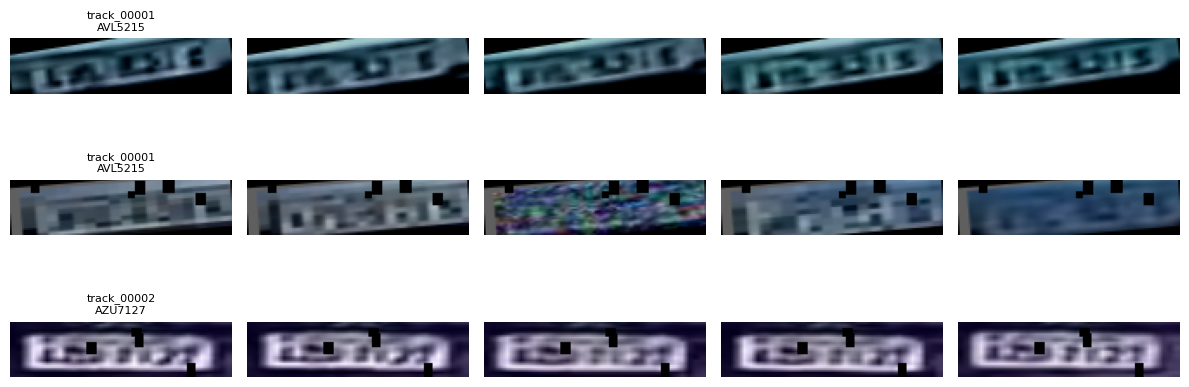

In [11]:
def show_batch(dataset: MultiFrameDataset, n: int = 3) -> None:
    n = min(n, len(dataset))
    fig, axes = plt.subplots(n, config.NUM_FRAMES, figsize=(config.NUM_FRAMES * 2.4, n * 1.6))
    if n == 1:
        axes = np.expand_dims(axes, 0)
    for row in range(n):
        frames, _, _, label, track_id = dataset[row]
        for col in range(config.NUM_FRAMES):
            img = frames[col].permute(1, 2, 0).numpy()
            img = (img * 0.5 + 0.5).clip(0, 1)
            axes[row, col].imshow(img)
            axes[row, col].axis("off")
            if col == 0:
                axes[row, col].set_title(f"{track_id}\n{label}", fontsize=8)
    plt.tight_layout()
    plt.show()

show_batch(train_ds, n=3)


## 11. Build Model

In [12]:
if config.MODEL_TYPE == "restran":
    base_model = ResTranOCR(
        num_classes=config.NUM_CLASSES,
        transformer_heads=config.TRANSFORMER_HEADS,
        transformer_layers=config.TRANSFORMER_LAYERS,
        transformer_ff_dim=config.TRANSFORMER_FF_DIM,
        dropout=config.TRANSFORMER_DROPOUT,
        use_stn=config.USE_STN,
    )
elif config.MODEL_TYPE == "crnn":
    base_model = MultiFrameCRNN(
        num_classes=config.NUM_CLASSES,
        hidden_size=config.HIDDEN_SIZE,
        rnn_dropout=config.RNN_DROPOUT,
        use_stn=config.USE_STN,
    )
else:
    raise ValueError(f"Unknown MODEL_TYPE: {config.MODEL_TYPE}")

base_model = base_model.to(config.DEVICE)
if config.USE_DATA_PARALLEL:
    model = nn.DataParallel(base_model)
    print(f"DataParallel enabled on {config.N_GPUS} GPUs")
else:
    model = base_model

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {config.MODEL_TYPE}")
print(f"Device: {config.DEVICE} | GPUs: {config.N_GPUS} | DataParallel: {config.USE_DATA_PARALLEL}")
print(f"Batch size: {config.BATCH_SIZE} | Num workers: {config.NUM_WORKERS}")
print(f"USE_STN: {config.USE_STN} | USE_AMP: {config.USE_AMP} | CUDNN benchmark: {config.USE_CUDNN_BENCHMARK}")
print(f"Parameters: {n_params:,} total, {n_trainable:,} trainable")


DataParallel enabled on 2 GPUs
Model: restran
Device: cuda | GPUs: 2 | DataParallel: True
Batch size: 64 | Num workers: 4
USE_STN: False | USE_AMP: False | CUDNN benchmark: False
Parameters: 30,793,702 total, 30,793,702 trainable


## 12. Train

In [13]:
trainer = Trainer(model=model, train_loader=train_loader, val_loader=val_loader, config=config, idx2char=config.IDX2CHAR)
trainer.fit()


Training on cuda for 30 epochs


Validation: 100%|██████████| 16/16 [00:06<00:00,  2.50it/s]


Epoch 1/30: train_loss=2.9570 val_loss=2.7199 val_acc=0.00%


Validation: 100%|██████████| 16/16 [00:02<00:00,  6.12it/s]


Epoch 2/30: train_loss=2.5738 val_loss=2.1937 val_acc=0.20%
Saved model: /kaggle/working/results/restran_t4_kaggle_best.pth
Saved 999 lines: /kaggle/working/results/submission_restran_t4_kaggle_val.txt


...

Epoch 28/30: train_loss=0.1090 val_loss=0.2422 val_acc=71.07%
Saved model: /kaggle/working/results/restran_t4_kaggle_best.pth
Saved 999 lines: /kaggle/working/results/submission_restran_t4_kaggle_val.txt


Validation: 100%|██████████| 16/16 [00:03<00:00,  4.27it/s]


Epoch 29/30: train_loss=0.1054 val_loss=0.2414 val_acc=71.07%


Validation: 100%|██████████| 16/16 [00:03<00:00,  4.49it/s]


Epoch 30/30: train_loss=0.1031 val_loss=0.2413 val_acc=71.67%
Saved model: /kaggle/working/results/restran_t4_kaggle_best.pth
Saved 999 lines: /kaggle/working/results/submission_restran_t4_kaggle_val.txt
Done. Best validation accuracy: 71.67%


## 13. Public Test Inference

In [14]:
def load_model_weights(model: nn.Module, checkpoint_path: str, device: torch.device) -> None:
    state_dict = torch.load(checkpoint_path, map_location=device)
    target = model.module if isinstance(model, nn.DataParallel) else model
    target.load_state_dict(state_dict)


def run_test_inference(test_root: Optional[str], test_name: str, output_filename: str) -> Optional[str]:
    if test_root is None:
        print(f"No {test_name} test folder found. Skipping.")
        return None

    test_ds = MultiFrameDataset(
        root_dir=test_root,
        mode="val",
        img_height=config.IMG_HEIGHT,
        img_width=config.IMG_WIDTH,
        num_frames=config.NUM_FRAMES,
        char2idx=config.CHAR2IDX,
        seed=config.SEED,
        is_test=True,
    )
    if len(test_ds) == 0:
        print(f"{test_name} test dataset is empty. Skipping.")
        return None

    test_loader = DataLoader(
        test_ds,
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        collate_fn=MultiFrameDataset.collate_fn,
        num_workers=config.NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    print(f"Running {test_name} inference on {len(test_ds)} tracks from {test_root}")
    return trainer.predict_test(test_loader, output_filename=output_filename)


best_model_path = os.path.join(config.OUTPUT_DIR, f"{config.EXPERIMENT_NAME}_best.pth")
if os.path.exists(best_model_path):
    load_model_weights(model, best_model_path, config.DEVICE)
    print("Loaded best model:", best_model_path)
else:
    print("Best model checkpoint not found; using current model weights:", best_model_path)

public_submission_path = run_test_inference(
    config.PUBLIC_TEST_ROOT,
    "public",
    f"submission_{config.EXPERIMENT_NAME}_public.txt",
)
blind_submission_path = run_test_inference(
    config.BLIND_TEST_ROOT,
    "blind",
    f"submission_{config.EXPERIMENT_NAME}_blind.txt",
)

# Kaggle submissions should usually target the blind test. Keep a canonical submission.txt.
primary_source = blind_submission_path or public_submission_path
if primary_source is not None:
    final_submission_path = os.path.join(config.OUTPUT_DIR, "submission.txt")
    with open(primary_source, "r", encoding="utf-8") as src, open(final_submission_path, "w", encoding="utf-8") as dst:
        dst.write(src.read())
    print("Primary submission file:", final_submission_path)
else:
    print("No test predictions were generated.")


Loaded best model: /kaggle/working/results/restran_t4_kaggle_best.pth
[VAL] Scanning: /kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/Pa7a3Hin-test-public/Pa7a3Hin-test-public


Indexing test: 100%|██████████| 1000/1000 [00:01<00:00, 828.76it/s]


[VAL] Total samples: 1000
Running public inference on 1000 tracks from /kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/Pa7a3Hin-test-public/Pa7a3Hin-test-public


Test inference: 100%|██████████| 16/16 [00:08<00:00,  1.83it/s]


Saved 1000 lines: /kaggle/working/results/submission_restran_t4_kaggle_public.txt
[VAL] Scanning: /kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/TKzFBtn7-test-blind/TKzFBtn7-test-blind


Indexing test: 100%|██████████| 3000/3000 [00:03<00:00, 994.99it/s] 


[VAL] Total samples: 3000
Running blind inference on 3000 tracks from /kaggle/input/datasets/trunghiu/icpr-car-plate-dataset/TKzFBtn7-test-blind/TKzFBtn7-test-blind


Test inference: 100%|██████████| 47/47 [00:22<00:00,  2.11it/s]

Saved 3000 lines: /kaggle/working/results/submission_restran_t4_kaggle_blind.txt
Primary submission file: /kaggle/working/results/submission.txt


## 14. Output Files

In [15]:
print("Files in output dir:")
for path in sorted(Path(config.OUTPUT_DIR).glob("*")):
    print(path, path.stat().st_size, "bytes")


Files in output dir:
/kaggle/working/results/restran_t4_kaggle_best.pth 133577600 bytes
/kaggle/working/results/submission.txt 80979 bytes
/kaggle/working/results/submission_restran_t4_kaggle_blind.txt 80979 bytes
/kaggle/working/results/submission_restran_t4_kaggle_public.txt 26992 bytes
/kaggle/working/results/submission_restran_t4_kaggle_val.txt 26963 bytes
